### 0. Content page

1. Load packages and data
2. Helper functions
3. Rebuild long / short / net returns
4. Core performance table
5. Cumulative performance plot: Long / Short / Net
6. Drawdown plot
7. Return histogram
8. Long vs short correlation and descriptive stats
9. Signal diagnostics: E/P and P/B
10. Universe size over time
11. Portfolio breadth over time
12. Long vs short composition
13. Benchmark comparison vs S&P 500
14. Turnover
15. A compact text summary cell for every model

### 1. Load packages and data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
RESULT_DIR = "../tables/carhart4_top1000_market_cap_top50_long_top50_short"

In [3]:
portfolio_returns = pd.read_csv(f"{RESULT_DIR}/portfolio_returns.csv")
asset_returns = pd.read_csv(f"{RESULT_DIR}/asset_returns.csv")
weights_at_E = pd.read_csv(f"{RESULT_DIR}/weights_at_E.csv")
signals_at_T = pd.read_csv(f"{RESULT_DIR}/signals_at_T.csv")

# optional
try:
    portfolio_membership_at_T = pd.read_csv(f"{RESULT_DIR}/portfolio_membership_at_T.csv")
except FileNotFoundError:
    portfolio_membership_at_T = None

In [4]:
# parse dates
for c in ["signal_date", "execution_date", "next_execution_date"]:
    if c in portfolio_returns.columns:
        portfolio_returns[c] = pd.to_datetime(portfolio_returns[c])

for c in ["signal_date", "execution_date", "next_execution_date", "actual_exit_date"]:
    if c in asset_returns.columns:
        asset_returns[c] = pd.to_datetime(asset_returns[c])

for c in ["signal_date", "execution_date"]:
    if c in weights_at_E.columns:
        weights_at_E[c] = pd.to_datetime(weights_at_E[c])

if "signal_date" in signals_at_T.columns:
    signals_at_T["signal_date"] = pd.to_datetime(signals_at_T["signal_date"])

if portfolio_membership_at_T is not None:
    for c in ["signal_date", "execution_date"]:
        if c in portfolio_membership_at_T.columns:
            portfolio_membership_at_T[c] = pd.to_datetime(portfolio_membership_at_T[c])

In [5]:
print("portfolio_returns:", portfolio_returns.shape)
print("asset_returns:", asset_returns.shape)
print("weights_at_E:", weights_at_E.shape)
print("signals_at_T:", signals_at_T.shape)
if portfolio_membership_at_T is not None:
    print("portfolio_membership_at_T:", portfolio_membership_at_T.shape)

portfolio_returns: (238, 4)
asset_returns: (23797, 11)
weights_at_E: (23797, 26)
signals_at_T: (237647, 22)
portfolio_membership_at_T: (23797, 25)


### 2. Helper functions

In [6]:
def annualized_sharpe(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if monthly_returns.std() == 0:
        return np.nan
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

def max_drawdown(return_series: pd.Series) -> float:
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series: pd.Series) -> pd.Series:
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

### 3. Rebuild long / short / net returns

In [7]:
ls_monthly = (
    asset_returns
    .groupby(["signal_date", "execution_date", "next_execution_date", "side"], as_index=False)["weighted_return"]
    .sum()
    .pivot(
        index=["signal_date", "execution_date", "next_execution_date"],
        columns="side",
        values="weighted_return"
    )
    .reset_index()
)

ls_monthly.columns.name = None

for col in ["long", "short"]:
    if col not in ls_monthly.columns:
        ls_monthly[col] = 0.0

ls_monthly = ls_monthly.rename(columns={
    "long": "long_return",
    "short": "short_return"
})

ls_monthly["portfolio_return_rebuilt"] = (
    ls_monthly["long_return"] + ls_monthly["short_return"]
)

ls_monthly.head()

,signal_date,execution_date,next_execution_date,long_return,short_return,portfolio_return_rebuilt
0,2006-02-28,2006-03-01,2006-04-03,0.021826,-0.007382,0.014444
1,2006-03-31,2006-04-03,2006-05-01,-0.004372,0.003077,-0.001295
2,2006-04-28,2006-05-01,2006-06-01,-0.007425,0.030486,0.023061
3,2006-05-31,2006-06-01,2006-07-03,-0.002919,0.014010,0.011091
4,2006-06-30,2006-07-03,2006-08-01,-0.012740,0.031464,0.018723


In [8]:
# optional consistency check against saved portfolio_returns.csv
check = portfolio_returns.merge(
    ls_monthly,
    on=["signal_date", "execution_date", "next_execution_date"],
    how="inner"
)

check["diff"] = check["portfolio_return"] - check["portfolio_return_rebuilt"]

print("max abs diff:", check["diff"].abs().max())
print("nonzero diff rows:", (check["diff"].abs() > 1e-12).sum())

max abs diff: 3.83026943495679e-15
nonzero diff rows: 0


### 4. Core performance table

In [9]:
summary_table = pd.DataFrame({
    "long_leg": performance_summary(ls_monthly["long_return"]),
    "short_leg": performance_summary(ls_monthly["short_return"]),
    "net_portfolio": performance_summary(ls_monthly["portfolio_return_rebuilt"]),
}).T

summary_table

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
long_leg,0.005562,0.034032,0.566178,0.605042,-0.292536
short_leg,-0.005209,0.054437,-0.331486,0.453782,-0.875187
net_portfolio,0.000353,0.048894,0.025013,0.537815,-0.640056


### 5. Cumulative performance plot: Long / Short / Net

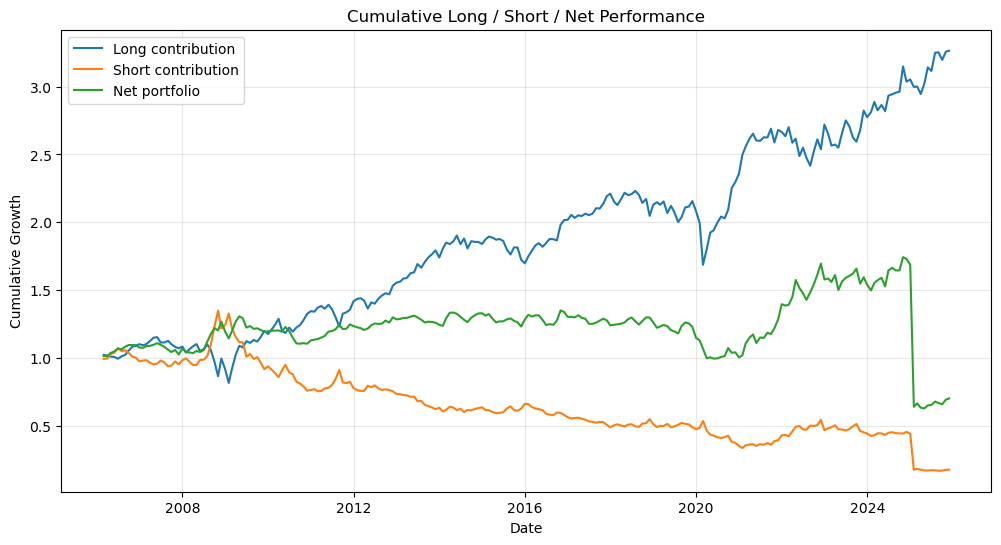

In [10]:
plot_df = ls_monthly.sort_values("signal_date").copy()

plot_df["cum_long"] = (1 + plot_df["long_return"]).cumprod()
plot_df["cum_short"] = (1 + plot_df["short_return"]).cumprod()
plot_df["cum_net"] = (1 + plot_df["portfolio_return_rebuilt"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["signal_date"], plot_df["cum_long"], label="Long contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_short"], label="Short contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_net"], label="Net portfolio")
plt.title("Cumulative Long / Short / Net Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6. Drawdown plot

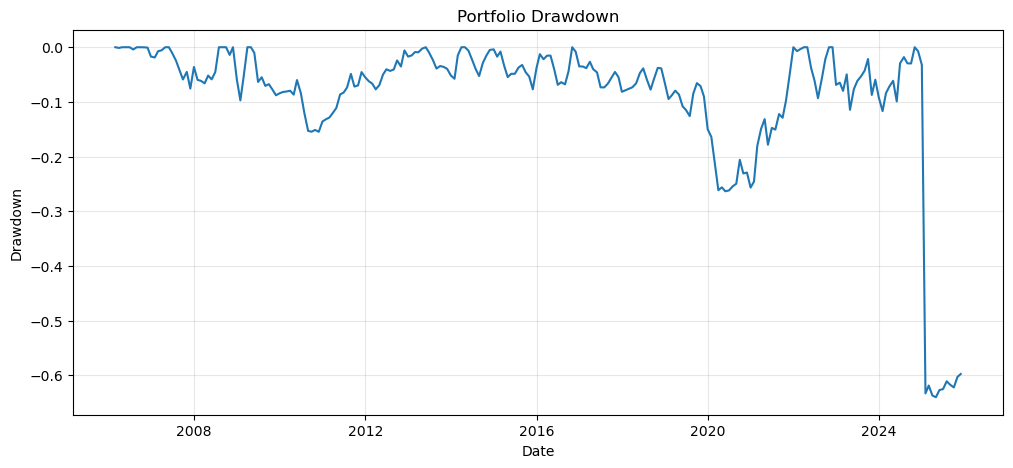

In [11]:
drawdown_df = plot_df[["signal_date", "portfolio_return_rebuilt"]].copy()
drawdown_df["cum"] = (1 + drawdown_df["portfolio_return_rebuilt"]).cumprod()
drawdown_df["roll_max"] = drawdown_df["cum"].cummax()
drawdown_df["drawdown"] = drawdown_df["cum"] / drawdown_df["roll_max"] - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown_df["signal_date"], drawdown_df["drawdown"])
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

### 7. Return histogram

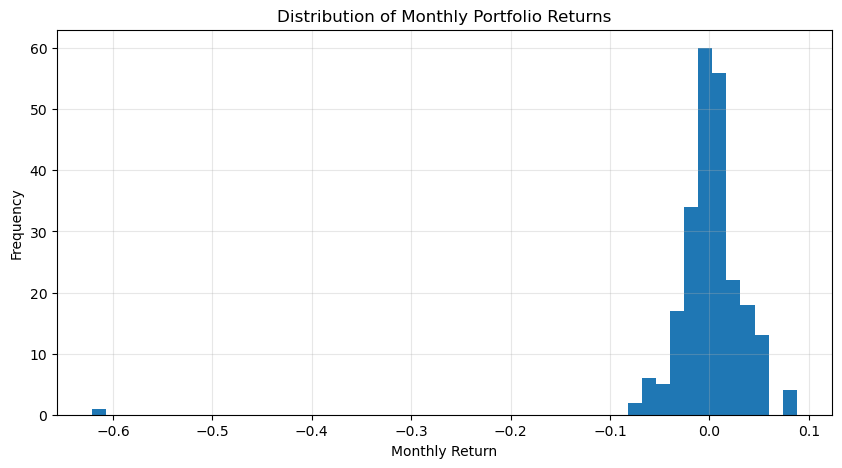

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(ls_monthly["portfolio_return_rebuilt"], bins=50)
plt.title("Distribution of Monthly Portfolio Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### 8. Long vs short correlation and descriptive stats

In [13]:
corr_ls = ls_monthly["long_return"].corr(ls_monthly["short_return"])
print("Correlation between long and short contributions:", corr_ls)

Correlation between long and short contributions: -0.46715547874827784


In [14]:
ls_monthly[["long_return", "short_return", "portfolio_return_rebuilt"]].describe()

,long_return,short_return,portfolio_return_rebuilt
count,238.000000,238.000000,238.000000
mean,0.005562,-0.005209,0.000353
std,0.034032,0.054437,0.048894
min,-0.153791,-0.602990,-0.620838
25%,-0.011357,-0.024280,-0.012802
50%,0.008515,-0.003751,0.002226
75%,0.023641,0.017173,0.014884
max,0.151293,0.122181,0.087988


In [15]:
# gross-normalized leg returns assuming 0.5 gross long / 0.5 gross short
ls_monthly["long_book_raw_return"] = ls_monthly["long_return"] / 0.5
ls_monthly["short_book_pnl_per_gross"] = ls_monthly["short_return"] / 0.5

ls_monthly[[
    "long_return",
    "short_return",
    "long_book_raw_return",
    "short_book_pnl_per_gross"
]].describe()

,long_return,short_return,long_book_raw_return,short_book_pnl_per_gross
count,238.000000,238.000000,238.000000,238.000000
mean,0.005562,-0.005209,0.011124,-0.010418
std,0.034032,0.054437,0.068064,0.108874
min,-0.153791,-0.602990,-0.307583,-1.205981
25%,-0.011357,-0.024280,-0.022714,-0.048559
50%,0.008515,-0.003751,0.017029,-0.007502
75%,0.023641,0.017173,0.047282,0.034346
max,0.151293,0.122181,0.302587,0.244361


### 9. Signal diagnostics: E/P and P/B

In [16]:
weights_at_E["ep"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    23797.000000
mean         1.998186
std         17.963942
min         -7.045949
1%          -0.161646
5%          -0.028139
50%          0.050056
95%          0.364748
99%         66.748703
max        495.557110
Name: ep, dtype: float64

In [17]:
weights_at_E["pb"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    2.379700e+04
mean     1.080945e+04
std      3.665920e+05
min      1.626957e-04
1%       1.755349e-03
5%       4.446156e-01
50%      2.874967e+00
95%      4.112279e+02
99%      2.766051e+04
max      3.773980e+07
Name: pb, dtype: float64

In [18]:
weights_at_E["mom_1m"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    23797.000000
mean        -0.002643
std          0.129861
min         -0.976400
1%          -0.365063
5%          -0.215019
50%          0.001167
95%          0.191909
99%          0.328876
max          1.590062
Name: mom_1m, dtype: float64

In [19]:
weights_at_E["ep"].sort_values(ascending=False).head(10)

23708    495.557110
23605    495.557110
11846    448.368642
11941    435.411199
22719    398.383018
22814    395.654367
22909    389.780955
23001    356.662599
2114     352.815624
22404    345.901423
Name: ep, dtype: float64

In [20]:
weights_at_E["pb"].sort_values(ascending=False).head(10)

15290    3.773980e+07
9574     1.755752e+07
9497     1.696346e+07
9173     1.406745e+07
9097     1.257912e+07
9297     1.243732e+07
10297    1.069423e+07
10096    9.003178e+06
9972     8.655529e+06
8797     7.853785e+06
Name: pb, dtype: float64

In [21]:
weights_at_E["mom_1m"].sort_values(ascending=False).head(10)

21044    1.590062
3800     0.903688
3836     0.899098
3843     0.869338
3817     0.838951
3942     0.769231
3806     0.757463
3808     0.757261
3802     0.755076
3826     0.735672
Name: mom_1m, dtype: float64

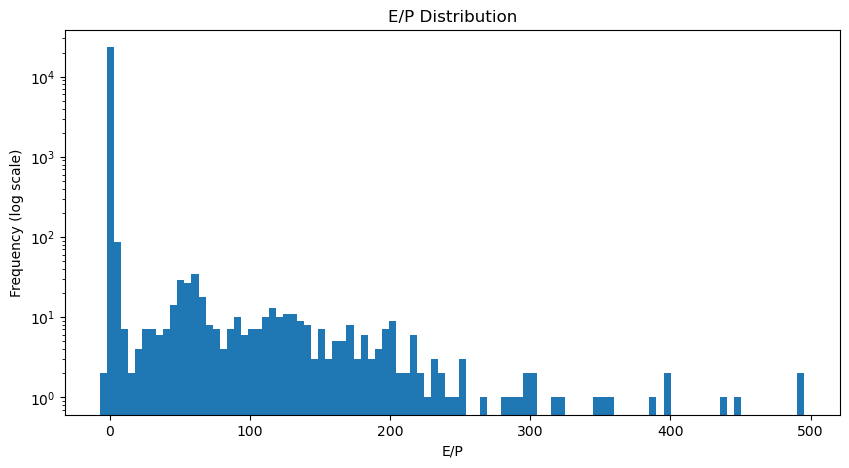

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["ep"], bins=100)
plt.yscale("log")
plt.title("E/P Distribution")
plt.xlabel("E/P")
plt.ylabel("Frequency (log scale)")
plt.show()

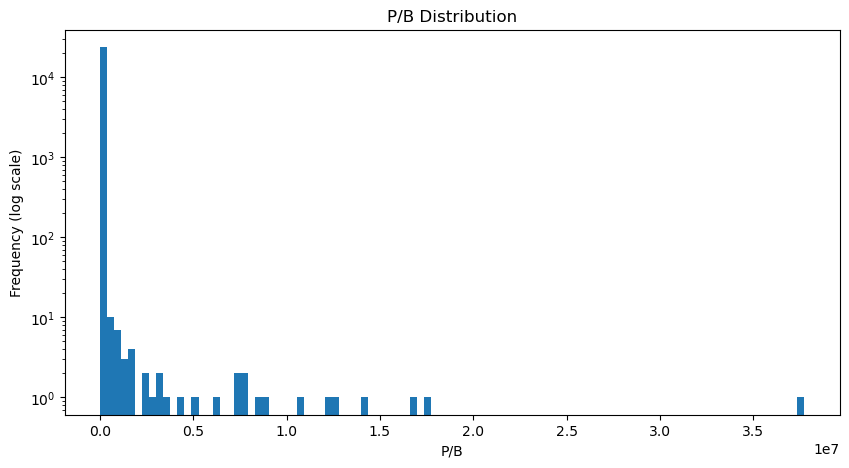

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["pb"], bins=100)
plt.yscale("log")
plt.title("P/B Distribution")
plt.xlabel("P/B")
plt.ylabel("Frequency (log scale)")
plt.show()

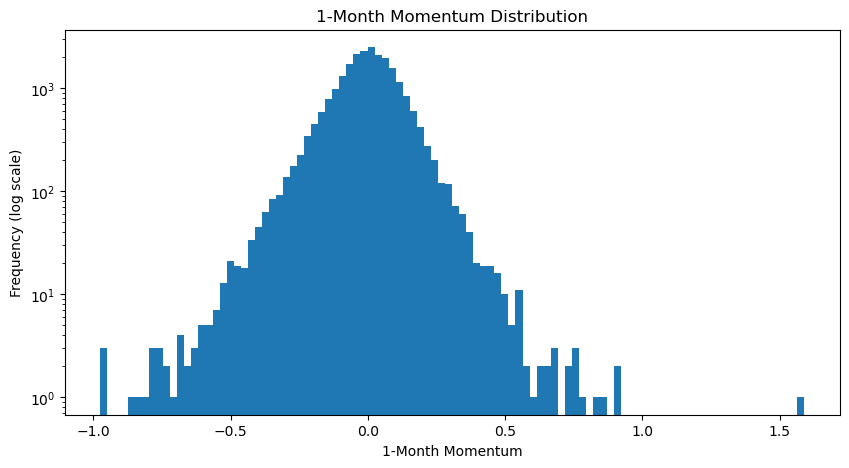

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["mom_1m"], bins=100)
plt.yscale("log")
plt.title("1-Month Momentum Distribution")
plt.xlabel("1-Month Momentum")
plt.ylabel("Frequency (log scale)")
plt.show()

### 10. Universe size over time

In [25]:
universe_size = (
    signals_at_T.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_universe")
)

universe_size.head()

,signal_date,n_universe
0,2006-02-28,1000
1,2006-03-31,999
2,2006-04-28,999
3,2006-05-31,998
4,2006-06-30,1000


In [26]:
universe_size["n_universe"].describe()

count     238.000000
mean      998.516807
std         1.454562
min       993.000000
25%       998.000000
50%       999.000000
75%      1000.000000
max      1000.000000
Name: n_universe, dtype: float64

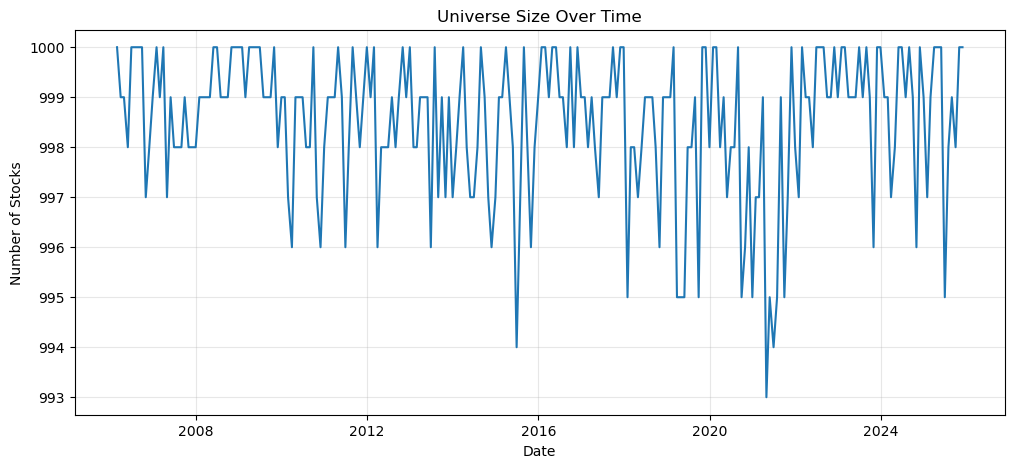

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(universe_size["signal_date"], universe_size["n_universe"])
plt.title("Universe Size Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)
plt.show()

### 11. Portfolio breadth over time

In [28]:
breadth = (
    asset_returns
    .groupby(["signal_date", "side"])["ticker"]
    .nunique()
    .unstack()
    .reset_index()
    .rename(columns={"long": "n_long", "short": "n_short"})
)

breadth.head()

side,signal_date,n_long,n_short
0,2006-02-28,50,50
1,2006-03-31,50,50
2,2006-04-28,50,50
3,2006-05-31,50,50
4,2006-06-30,50,50


In [29]:
breadth[["n_long", "n_short"]].describe()

side,n_long,n_short
count,238.000000,238.0
mean,49.987395,50.0
std,0.111797,0.0
min,49.000000,50.0
25%,50.000000,50.0
50%,50.000000,50.0
75%,50.000000,50.0
max,50.000000,50.0


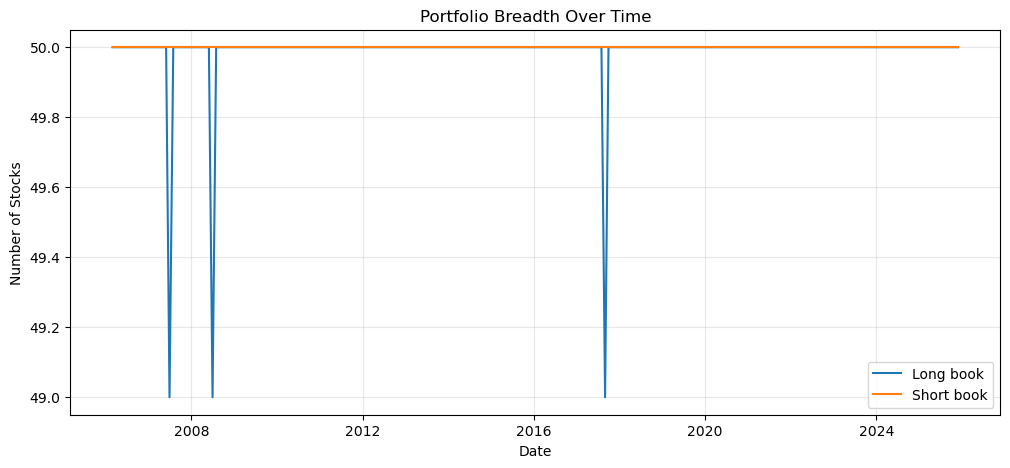

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(breadth["signal_date"], breadth["n_long"], label="Long book")
plt.plot(breadth["signal_date"], breadth["n_short"], label="Short book")
plt.title("Portfolio Breadth Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12. Long vs short composition

In [31]:
factor_summary_by_side = (
    weights_at_E.groupby("side")[["market_cap", "pb", "ep", "mom_1m"]]
    .mean()
)

factor_summary_by_side

,market_cap,pb,ep,mom_1m
side,,,,
long,4.054432e+09,1.225948,3.998634,0.079051
short,4.153243e+11,21614.947311,-0.001757,-0.084317


In [32]:
factor_check = (
    weights_at_E
    .groupby(["signal_date", "side"])
    .agg({
        "market_cap": "mean",
        "pb": "mean",
        "ep": "mean",
        "mom_1m": "mean"
    })
    .reset_index()
    .pivot(index="signal_date", columns="side")
)

factor_check.columns = ["_".join(col) for col in factor_check.columns]
factor_check = factor_check.reset_index()

factor_check.head()

,signal_date,market_cap_long,market_cap_short,pb_long,pb_short,ep_long,ep_short,mom_1m_long,mom_1m_short
0,2006-02-28,1.050562e+09,2.510518e+10,1.392802,83.180122,1.389563,0.007296,0.063247,-0.096760
1,2006-03-31,1.016451e+09,2.123592e+10,1.419605,127.768878,0.163271,0.002254,0.076970,-0.063655
2,2006-04-28,2.036479e+09,2.063911e+10,1.288344,122.238210,2.896332,0.006283,0.072394,-0.072268
3,2006-05-31,1.204679e+09,1.850074e+10,1.482978,261.064857,0.121339,-0.000103,0.027071,-0.134341
4,2006-06-30,9.482090e+08,1.946689e+10,1.406550,187.101904,0.131086,0.003637,0.065395,-0.093344


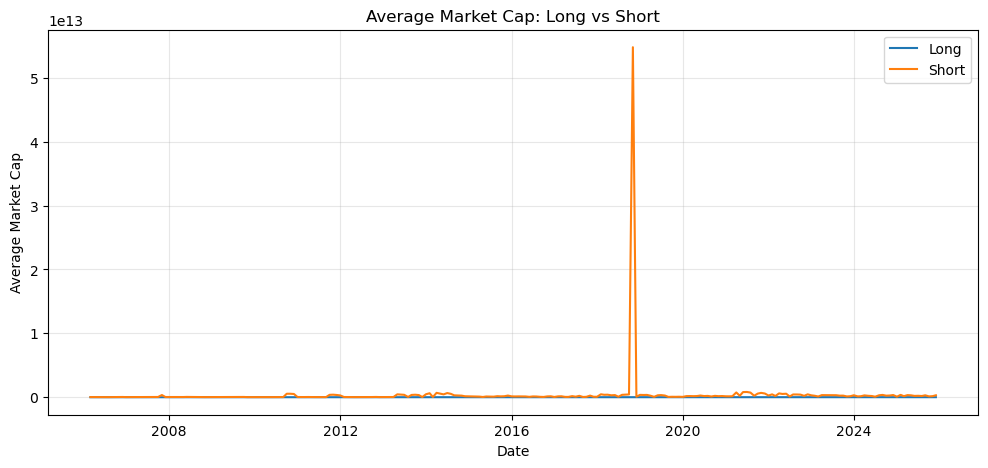

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["market_cap_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["market_cap_short"], label="Short")
plt.title("Average Market Cap: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average Market Cap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

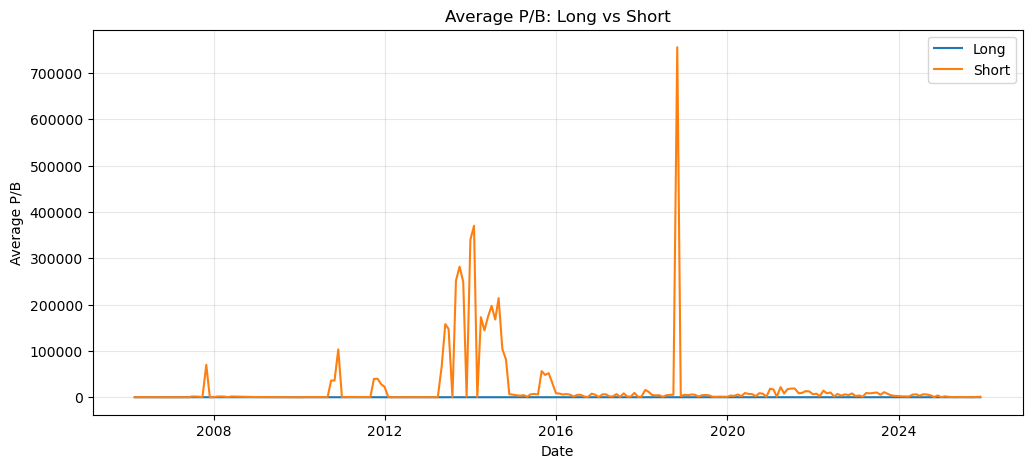

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["pb_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["pb_short"], label="Short")
plt.title("Average P/B: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average P/B")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

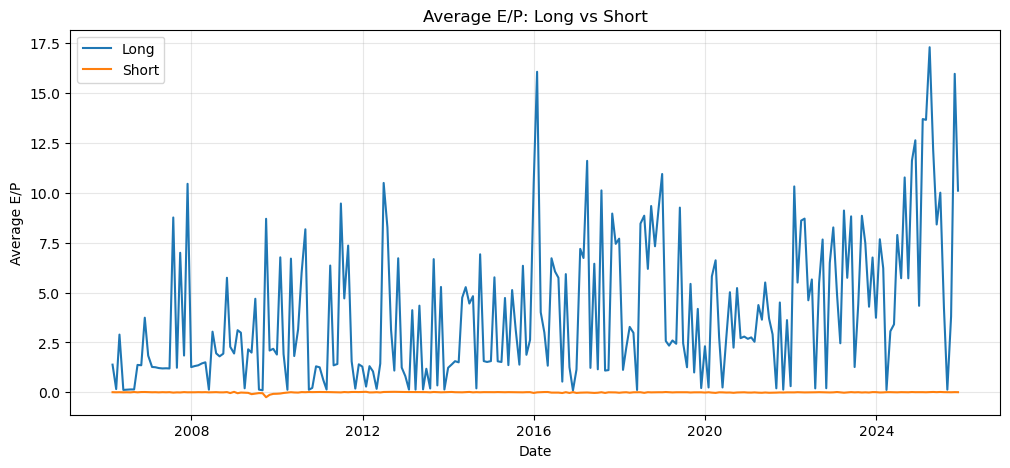

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["ep_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["ep_short"], label="Short")
plt.title("Average E/P: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average E/P")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

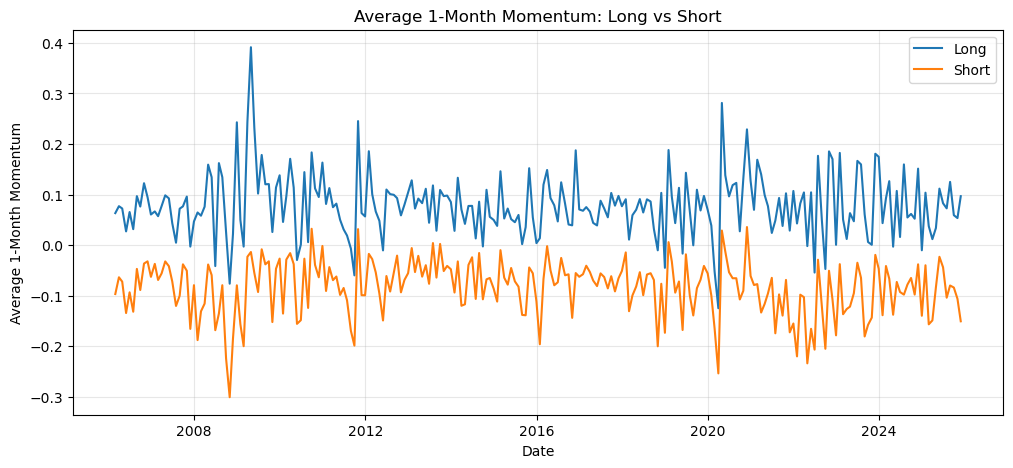

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["mom_1m_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["mom_1m_short"], label="Short")
plt.title("Average 1-Month Momentum: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average 1-Month Momentum")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 13. Benchmark comparison vs S&P 500

In [37]:
sp = yf.download(
    "^GSPC",
    start="1996-01-01",
    end="2026-01-01",
    progress=False,
    auto_adjust=False
)

sp_price = sp[("Adj Close", "^GSPC")]

sp_monthly = (
    sp_price
    .resample("ME")
    .last()
    .pct_change()
    .dropna()
    .to_frame("sp_return")
    .reset_index()
    .rename(columns={"Date": "signal_date"})
)

sp_monthly["signal_date"] = pd.to_datetime(sp_monthly["signal_date"])

sp_monthly.head()

,signal_date,sp_return
0,1996-02-29,0.006934
1,1996-03-31,0.007917
2,1996-04-30,0.013431
3,1996-05-31,0.022853
4,1996-06-30,0.002257


In [38]:
portfolio_returns["signal_date"] = pd.to_datetime(portfolio_returns["signal_date"])
portfolio_returns.head()

,signal_date,execution_date,next_execution_date,portfolio_return
0,2006-02-28,2006-03-01,2006-04-03,0.014444
1,2006-03-31,2006-04-03,2006-05-01,-0.001295
2,2006-04-28,2006-05-01,2006-06-01,0.023061
3,2006-05-31,2006-06-01,2006-07-03,0.011091
4,2006-06-30,2006-07-03,2006-08-01,0.018723


In [39]:
portfolio_returns = portfolio_returns.sort_values("signal_date").reset_index(drop=True)
sp_monthly = sp_monthly.sort_values("signal_date").reset_index(drop=True)

In [40]:
merged = pd.merge(
    portfolio_returns,
    sp_monthly,
    on="signal_date",
    how="inner"
)

print(merged.shape)
merged.head()

(168, 5)


,signal_date,execution_date,next_execution_date,portfolio_return,sp_return
0,2006-02-28,2006-03-01,2006-04-03,0.014444,0.000453
1,2006-03-31,2006-04-03,2006-05-01,-0.001295,0.011096
2,2006-05-31,2006-06-01,2006-07-03,0.011091,-0.030917
3,2006-06-30,2006-07-03,2006-08-01,0.018723,0.000087
4,2006-07-31,2006-08-01,2006-09-01,-0.004115,0.005086


In [41]:
merged["cum_carhart4"] = (1 + merged["portfolio_return"]).cumprod()
merged["cum_sp"] = (1 + merged["sp_return"]).cumprod()

merged[["signal_date", "portfolio_return", "sp_return", "cum_carhart4", "cum_sp"]].head()

,signal_date,portfolio_return,sp_return,cum_carhart4,cum_sp
0,2006-02-28,0.014444,0.000453,1.014444,1.000453
1,2006-03-31,-0.001295,0.011096,1.013131,1.011554
2,2006-05-31,0.011091,-0.030917,1.024367,0.980280
3,2006-06-30,0.018723,0.000087,1.043547,0.980365
4,2006-07-31,-0.004115,0.005086,1.039253,0.985351


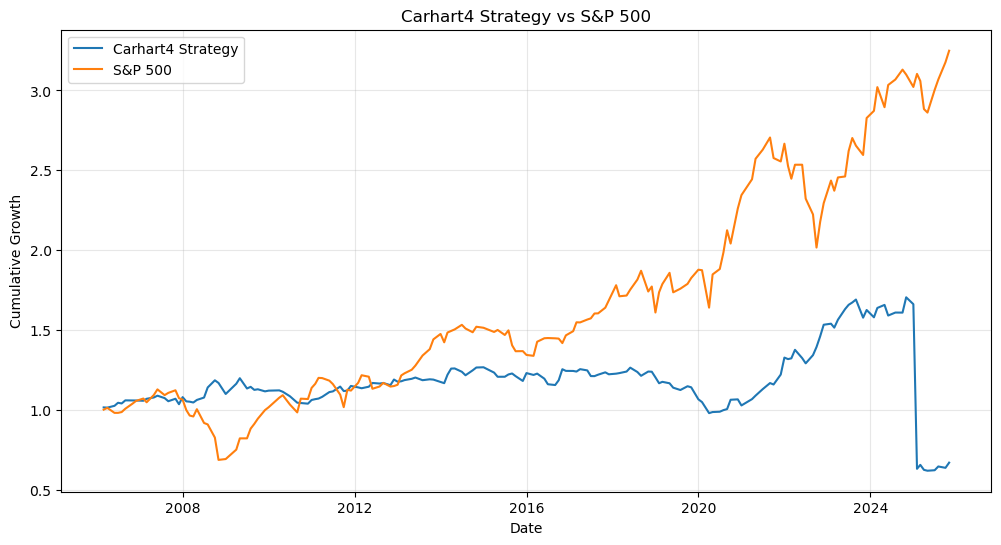

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(merged["signal_date"], merged["cum_carhart4"], label="Carhart4 Strategy")
plt.plot(merged["signal_date"], merged["cum_sp"], label="S&P 500")
plt.title("Carhart4 Strategy vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
def annualized_sharpe(monthly_returns):
    monthly_returns = monthly_returns.dropna()
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

print("Carhart4 Sharpe:", annualized_sharpe(merged["portfolio_return"]))
print("S&P 500 Sharpe:", annualized_sharpe(merged["sp_return"]))

Carhart4 Sharpe: 0.001448687549595709
S&P 500 Sharpe: 0.6271436596297293


In [44]:
def max_drawdown(return_series):
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series):
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

benchmark_summary = pd.DataFrame({
    "Carhart4 Strategy": performance_summary(merged["portfolio_return"]),
    "S&P 500": performance_summary(merged["sp_return"]),
}).T

benchmark_summary

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
Carhart4 Strategy,0.000023,0.054820,0.001449,0.553571,-0.637456
S&P 500,0.008028,0.044342,0.627144,0.636905,-0.391858


### 14. Turnover

In [45]:
membership_sets = (
    weights_at_E.groupby("signal_date")["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
    .sort_values("signal_date")
    .reset_index(drop=True)
)

turnover_records = []
for i in range(1, len(membership_sets)):
    prev_set = membership_sets.loc[i - 1, "ticker_set"]
    curr_set = membership_sets.loc[i, "ticker_set"]

    entered = len(curr_set - prev_set)
    exited = len(prev_set - curr_set)
    union_n = len(curr_set | prev_set)
    prev_n = len(prev_set)

    turnover_records.append({
        "signal_date": membership_sets.loc[i, "signal_date"],
        "entered": entered,
        "exited": exited,
        "turnover_rate_vs_prev": (entered + exited) / prev_n if prev_n > 0 else np.nan,
        "jaccard_similarity": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
    })

turnover_df = pd.DataFrame(turnover_records)
turnover_df.head()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
0,2006-03-31,52,52,1.04,0.315789
1,2006-04-28,58,58,1.16,0.265823
2,2006-05-31,60,60,1.20,0.250000
3,2006-06-30,55,55,1.10,0.290323
4,2006-07-31,60,60,1.20,0.250000


In [46]:
turnover_df.describe()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
count,237,237.00000,237.000000,237.000000,237.000000
mean,2016-01-29 15:23:32.658227968,58.64557,58.645570,1.173066,0.262447
min,2006-03-31 00:00:00,41.00000,41.000000,0.820000,0.149425
25%,2011-02-28 00:00:00,54.00000,54.000000,1.080000,0.226994
50%,2016-01-29 00:00:00,59.00000,59.000000,1.180000,0.257862
75%,2020-12-31 00:00:00,63.00000,63.000000,1.260000,0.298701
max,2025-11-28 00:00:00,74.00000,74.000000,1.480000,0.418440
std,NaN,6.02756,6.022637,0.120558,0.048576


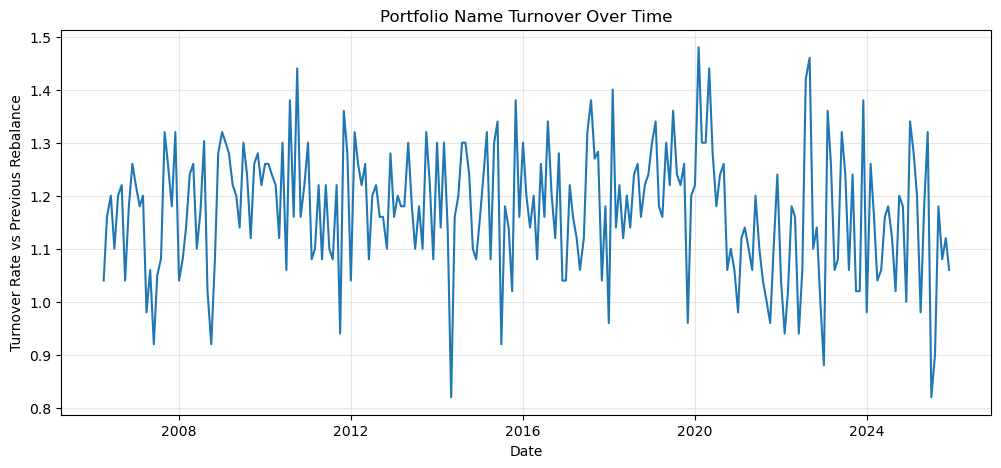

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_df["signal_date"], turnover_df["turnover_rate_vs_prev"])
plt.title("Portfolio Name Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover Rate vs Previous Rebalance")
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
side_sets = (
    weights_at_E.groupby(["signal_date", "side"])["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
)

long_sets = (
    side_sets[side_sets["side"] == "long"][["signal_date", "ticker_set"]]
    .sort_values("signal_date")
    .reset_index(drop=True)
)

short_sets = (
    side_sets[side_sets["side"] == "short"][["signal_date", "ticker_set"]]
    .sort_values("signal_date")
    .reset_index(drop=True)
)

In [49]:
def compute_turnover_from_sets(df_sets: pd.DataFrame, label: str) -> pd.DataFrame:
    records = []
    for i in range(1, len(df_sets)):
        prev_set = df_sets.loc[i - 1, "ticker_set"]
        curr_set = df_sets.loc[i, "ticker_set"]
        prev_n = len(prev_set)
        union_n = len(curr_set | prev_set)

        records.append({
            "signal_date": df_sets.loc[i, "signal_date"],
            f"{label}_turnover": (len(curr_set - prev_set) + len(prev_set - curr_set)) / prev_n if prev_n > 0 else np.nan,
            f"{label}_jaccard": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
        })
    return pd.DataFrame(records)

long_turnover = compute_turnover_from_sets(long_sets, "long")
short_turnover = compute_turnover_from_sets(short_sets, "short")

long_turnover.head(), short_turnover.head()

(  signal_date  long_turnover  long_jaccard
 0  2006-03-31           1.04      0.315789
 1  2006-04-28           1.24      0.234568
 2  2006-05-31           1.36      0.190476
 3  2006-06-30           1.08      0.298701
 4  2006-07-31           1.08      0.298701,
   signal_date  short_turnover  short_jaccard
 0  2006-03-31            1.04       0.315789
 1  2006-04-28            1.08       0.298701
 2  2006-05-31            1.04       0.315789
 3  2006-06-30            1.12       0.282051
 4  2006-07-31            1.32       0.204819)

In [50]:
turnover_side = long_turnover.merge(short_turnover, on="signal_date", how="inner")
turnover_side.head()

,signal_date,long_turnover,long_jaccard,short_turnover,short_jaccard
0,2006-03-31,1.04,0.315789,1.04,0.315789
1,2006-04-28,1.24,0.234568,1.08,0.298701
2,2006-05-31,1.36,0.190476,1.04,0.315789
3,2006-06-30,1.08,0.298701,1.12,0.282051
4,2006-07-31,1.08,0.298701,1.32,0.204819


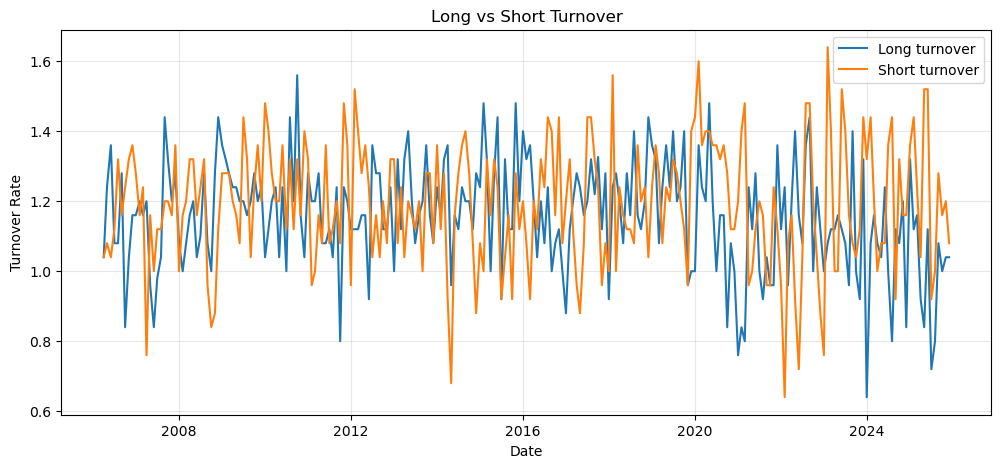

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_side["signal_date"], turnover_side["long_turnover"], label="Long turnover")
plt.plot(turnover_side["signal_date"], turnover_side["short_turnover"], label="Short turnover")
plt.title("Long vs Short Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 15. A compact text summary cell for every model

In [52]:
print("=== MODEL SUMMARY ===")
print(f"Net annualized Sharpe: {annualized_sharpe(ls_monthly['portfolio_return_rebuilt']):.4f}")
print(f"Long annualized Sharpe: {annualized_sharpe(ls_monthly['long_return']):.4f}")
print(f"Short annualized Sharpe: {annualized_sharpe(ls_monthly['short_return']):.4f}")
print(f"Long-short correlation: {ls_monthly['long_return'].corr(ls_monthly['short_return']):.4f}")
print(f"Max drawdown: {max_drawdown(ls_monthly['portfolio_return_rebuilt']):.4f}")
print(f"Average universe size: {universe_size['n_universe'].mean():.2f}")
print(f"Average long breadth: {breadth['n_long'].mean():.2f}")
print(f"Average short breadth: {breadth['n_short'].mean():.2f}")

=== MODEL SUMMARY ===
Net annualized Sharpe: 0.0250
Long annualized Sharpe: 0.5662
Short annualized Sharpe: -0.3315
Long-short correlation: -0.4672
Max drawdown: -0.6401
Average universe size: 998.52
Average long breadth: 49.99
Average short breadth: 50.00
